In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from urllib.request import urlretrieve

# 1. Preliminary data analysis

In [2]:
medical_charges_url = "https://raw.githubusercontent.com/JovianML/opendatasets/master/data/medical-charges.csv"
urlretrieve(medical_charges_url, "./data/medical-charges.csv")
medical_df = pd.read_csv('./data/medical-charges.csv')
medical_df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
medical_df_copy = medical_df.copy()

In [4]:
medical_df.shape

(1338, 7)

In [5]:
medical_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
medical_df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [7]:
target = "charges"
X = medical_df.drop(columns=[target])
y = medical_df[target]

X.shape, y.shape

((1338, 6), (1338,))

In [8]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['age', 'bmi', 'children']
Categorical features: ['sex', 'smoker', 'region']


In [9]:
binary_features = [col for col in categorical_features if medical_df[col].nunique() == 2]
ordinal_features = [] # if any are in order
onehot_features = [col for col in categorical_features if col not in binary_features + ordinal_features]

print("Binary features:", binary_features)
print("Ordinal features:", ordinal_features)
print("One-hot features:", onehot_features)

Binary features: ['sex', 'smoker']
Ordinal features: []
One-hot features: ['region']


## 2. Exploratory Analysis and Visualization

In [10]:
import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

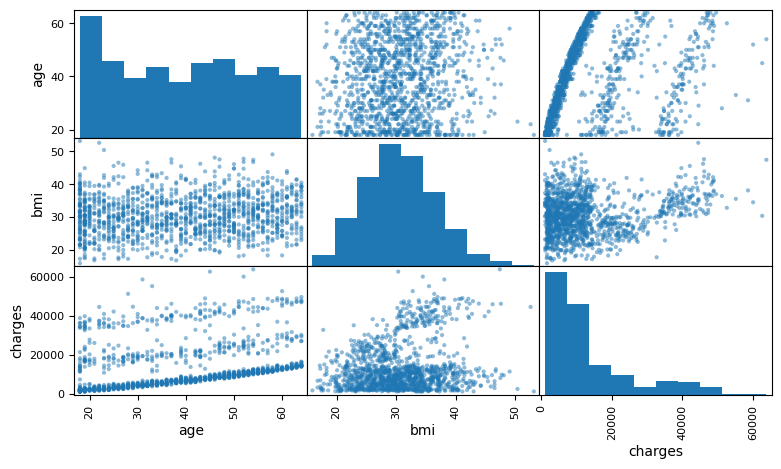

In [11]:
from pandas.plotting import scatter_matrix

attributes = ["age", "bmi", "smoker", "charges"]
scatter_matrix(medical_df[attributes], figsize=(9, 5))
plt.show()

### Age
Age is a numeric column. The minimum age in the dataset is 18 and the maximum age is 64. Thus, we can visualize the distribution of age using a histogram with 47 bins (one for each year) and a box plot.

In [12]:
medical_df.age.describe()

count    1338.000000
mean       39.207025
std        14.049960
min        18.000000
25%        27.000000
50%        39.000000
75%        51.000000
max        64.000000
Name: age, dtype: float64

In [13]:
fig = px.histogram(medical_df, 
                   x="age", 
                   marginal="box", 
                   nbins=47, 
                   title="Distribution of Age"
)
fig.update_layout(bargap=0.1)
fig.show()

### BMI - Body Mass Index

* `< 18.5` - underweight
* `18.5 - 24.9` - normal weight
* `25 - 29.9` - overweight
* `30 - 39.9` - obesity
* `> 40` - morbid obesity

In [14]:
medical_df.bmi.describe()

count    1338.000000
mean       30.663397
std         6.098187
min        15.960000
25%        26.296250
50%        30.400000
75%        34.693750
max        53.130000
Name: bmi, dtype: float64

In [15]:
fig = px.histogram(medical_df, 
                   x="bmi", 
                   marginal="box",
                   color_discrete_sequence=['indianred'], 
                   title="Distribution of BMI"
)
fig.update_layout(bargap=0.1)
fig.show()

The measurements of body mass index seem to form a [Gaussian distribution](https://www.youtube.com/watch?v=rzFX5NWojp0) centered around the value 30, with a few outliers towards the right.

### Charges

In [16]:
medical_df.charges.describe()

count     1338.000000
mean     13270.422265
std      12110.011237
min       1121.873900
25%       4740.287150
50%       9382.033000
75%      16639.912515
max      63770.428010
Name: charges, dtype: float64

In [17]:
fig = px.histogram(medical_df,
                   x='charges',
                   marginal='box',
                   color='smoker',
                   color_discrete_sequence=['green', 'lightseagreen'],
                   title='Distribution of Annual Medical Charges')
fig.update_layout(bargap=0.1)
fig.show()

We can make the following observations from the above graph:

For most customers, the annual medical charges are under $12k. Only a small fraction of customer have higher medical expenses - possibly due to accidents, major illnesses and genetic diseases. The distribution follows a "power law"
There is a significant difference in medical expenses between smokers and non-smokers. While the median for non-smokers is $7.3k, for smokers is close to $34k.


### Smokers

In [18]:
medical_df.smoker.value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

In [19]:
px.histogram(medical_df, x='smoker', color='sex', title='Smokers vs Non-Smokers')

It appears that 20% of customers have reported that they smoke.

### Region

In [20]:
medical_df.region.value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

In [21]:
px.histogram(medical_df, x="region", color="sex", title="Region")

* The number of insured persons in different regions of the country is rather even, with a slight preponderance in the southeast. 
* The number of insured persons by gender is also equal.

### Children

In [22]:
medical_df.children.value_counts()

children
0    574
1    324
2    240
3    157
4     25
5     18
Name: count, dtype: int64

In [23]:
px.histogram(medical_df, x="children", title="Number of Children")

* We can observe an interesting phenomenon here – the number of insured people decreases as the number of children increases.
* Interestingly, the number of insured people with one child drops by almost half compared to those without any children.
* Then, there's another significant drop for those with more than three children, with the percentage of insured persons accounting for only 4% of the childless population.

### Age and Annual Medical Charges

In [24]:
medical_df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [25]:
fig = px.scatter(medical_df,
                 x="age",
                 y="charges",
                 color="smoker",
                 opacity=0.8,
                 hover_data=["sex", "bmi"],
                 title="Age vs Annual Medical Charges"
)
fig.update_layout(legend=dict(x=0.02, y=0.98))
fig.update_traces(marker_size=6)
fig.show()

We can make the following observations from the above chart:

* The general trend seems to be that medical charges increase with age, as we might expect. However, there is significant variation at every age, and it's clear that age alone cannot be used to accurately determine medical charges.
* We can see three "clusters" of points, each of which seems to form a line with an increasing slope:

    1. The first and the largest cluster consists primary of presumably "healthy non-smokers" who have relatively low medical charges compared to others
    2. The second cluster contains a mix of smokers and non-smokers. It's possible that these are actually two distinct but overlapping clusters: "non-smokers with medical issues" and "smokers without major medical issues".
    3. The final cluster consists exclusively of smokers, presumably smokers with major medical issues that are possibly related to or worsened by smoking.

### BMI and Annual Medical Charges

In [26]:
fig = px.scatter(medical_df,
                 x='bmi',
                 y='charges',
                 color='smoker',
                 opacity=0.8,
                 hover_data=['sex'],
                 title='BMI vs Annual Medical Charges')
fig.update_traces(marker_size=6)
fig.update_layout(legend=dict(x=0.02, y=0.98))
fig.show()

It appears that for non-smokers, an increase in BMI doesn't seem to be related to an increase in medical charges. However, medical charges seem to be significantly higher for smokers with a BMI greater than 30 (obesity).

### Number of Children vs. Annual Medical Charges

In [27]:
fig = px.box(medical_df,
             x="children",
             y="charges",
             title="Annual Medical Charges by Number of Children",)
fig.show()  

For each number of children:
* The box shows the interquartile range (IQR): from the 25th percentile (Q1) to the 75th percentile (Q3).
* The line inside the box is the median (50th percentile).
* The "whiskers" extend to the smallest/largest values that are not considered outliers (typically up to 1.5×IQR).
* The dots above the whiskers are outliers – unusually high medical charges compared to the rest.

**Insights from the graph:**
* Distributions are quite similar across groups 0–3 children.
* Median charges hover around ~9–12k.
* The spread (IQR) is fairly wide.
* Outliers are common in every group – many people have very high medical charges (20k–60k+). This indicates some individuals incur extreme costs regardless of the number of children. 

**Families with 5 children:**
* Smaller sample sizes (which makes distributions narrower).
  
**General takeaway:**
* The number of children doesn’t strongly affect medical charges in this dataset.
* The variance is dominated by other factors (likely smoking status, age, BMI — which are known strong predictors in the "Medical Cost" dataset)

In [28]:
fig = px.violin(
    medical_df,
    x="children",
    y="charges",
    title="Annual Medical Charges by Number of Children",
)
fig.show()

### Average Annual Medical Charges vs. Number of Children 

In [29]:
fig = px.bar(
    medical_df.groupby("children", as_index=False)["charges"].mean(),
    x="children",
    y="charges",
    title="Average Medical Charges by Number of Children",
)
fig.show()

* The number of children does not appear to be a strong driver of medical costs.
* However:
    1. Charges drop noticeably for the small group with 5 children (~9k) - likely due to very few observations in this category → results may not be reliable.
    2. Families with 2, 3 or 4 children tend to have slightly higher medical charges.

### Annual Medical Charges by Region

In [30]:
fig = px.box(medical_df,
                x="region",
                y="charges",
                title="Annual Medical Charges by Region")
fig.show()

In [31]:
fig = px.violin(medical_df, 
                x="region", 
                y="charges", 
                title="Annual Medical Charges by Region")
fig.show()

Region does not appear to be a strong factor in determining annual medical charges. The median annual medical charges are quite similar across all regions.

# 3. Handling missing data

### No missing data

# 4. Encoding Categorical Features

In [32]:
binary_features, ordinal_features, onehot_features

(['sex', 'smoker'], [], ['region'])

In [33]:
smoker_values = {"no": 0, "yes": 1}
X["smoker"] = X["smoker"].map(smoker_values)

sex_values = {"female": 0, "male": 1}
X["sex"] = X["sex"].map(sex_values)

X.head()

,age,sex,bmi,children,smoker,region
0,19,0,27.900,0,1,southwest
1,18,1,33.770,1,0,southeast
2,28,1,33.000,3,0,southeast
3,33,1,22.705,0,0,northwest
4,32,1,28.880,0,0,northwest


In [34]:
# Binary encoding
#X[binary_features] = X[binary_features].apply(lambda col: col.map({col.unique()[0]: 0, col.unique()[1]: 1}))


In [35]:
# One-hot encoding
X = pd.get_dummies(
    X,
    columns=onehot_features,
    drop_first=True,  # to avoid linear dependence between the columns
)

X.head(3)

,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest
0,19,0,27.90,0,1,False,False,True
1,18,1,33.77,1,0,False,True,False
2,28,1,33.00,3,0,False,True,False


# 5. Transformation of Numerical Features 

In [36]:
from scipy.stats import skew

skewed_feats = X[numeric_features].apply(lambda x: skew(x)).sort_values(ascending=False)

right_skewed = skewed_feats[skewed_feats > 1].index.tolist()
left_skewed = skewed_feats[skewed_feats < -1].index.tolist()

print(skewed_feats)
print("Right-skewed features:", right_skewed)
print("Left-skewed features:", left_skewed)

children    0.937328
bmi         0.283729
age         0.055610
dtype: float64
Right-skewed features: []
Left-skewed features: []


In [37]:
y_log = np.log1p(y)
y_df = pd.DataFrame({"y": y, "y_log": y_log})
y_df.head()

,y,y_log
0,16884.92400,9.734236
1,1725.55230,7.453882
2,4449.46200,8.400763
3,21984.47061,9.998137
4,3866.85520,8.260455


In [38]:
X_corr_df = pd.concat([X, y_log], axis=1)
X_corr_df.drop(
    ["region_northwest", "region_southeast", "region_southwest"], axis=1, inplace=True
)
X_corr_df.head()

,age,sex,bmi,children,smoker,charges
0,19,0,27.900,0,1,9.734236
1,18,1,33.770,1,0,7.453882
2,28,1,33.000,3,0,8.400763
3,33,1,22.705,0,0,9.998137
4,32,1,28.880,0,0,8.260455


# 6. Initial Dependency Exploration

The values in some columns are more closely related to the values in "charges" compared to other columns, e.g. "age" and "charges" seem to grow together, whereas "bmi" and "charges" don't.

This relationship is often expressed numerically using a measure called the `correlation coefficient`, which can be computed using the `.corr` method of a Pandas series.
To compute the correlation for categorical columns, they must first be converted into numeric columns.

### Correlation

In [39]:
X_corr_df.corr()

,age,sex,bmi,children,smoker,charges
age,1.000000,-0.020856,0.109272,0.042469,-0.025019,0.527807
sex,-0.020856,1.000000,0.046371,0.017163,0.076185,0.005644
bmi,0.109272,0.046371,1.000000,0.012759,0.003750,0.132678
children,0.042469,0.017163,0.012759,1.000000,0.007673,0.161317
smoker,-0.025019,0.076185,0.003750,0.007673,1.000000,0.665539
charges,0.527807,0.005644,0.132678,0.161317,0.665539,1.000000


In [40]:
matplotlib.rcParams["font.size"] = 10
matplotlib.rcParams["figure.figsize"] = (10, 6)

Text(0.5, 1.0, 'Correlation Matrix')

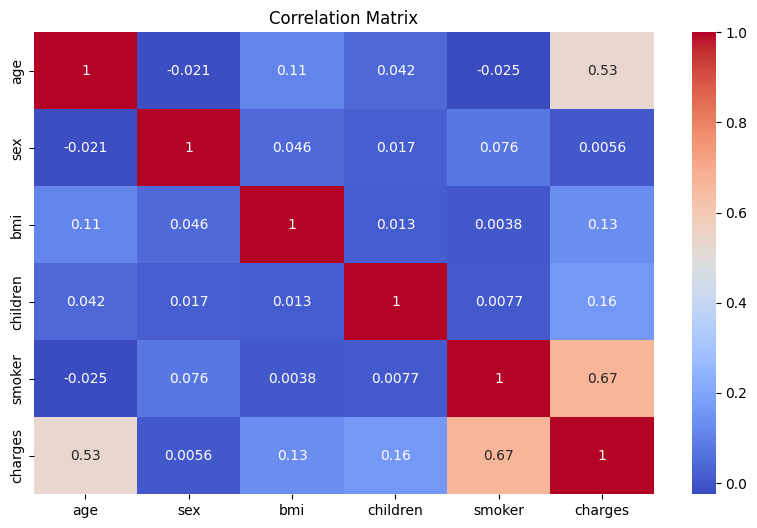

In [41]:
sns.heatmap(X_corr_df.corr(), cmap="coolwarm", annot=True)
plt.title("Correlation Matrix")

### Spearman for ordinal features

No ordinal features

In [42]:
# spearman_corr = (
#     X[ordinal_features].join(y_log.rename("charges_log")).corr(method="spearman")
# )
# print("\nSpearman correlation for ordinal features:")
# print(spearman_corr)

### Statistical tests – significance to target

In [43]:
X.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region_northwest',
       'region_southeast', 'region_southwest'],
      dtype='object')

In [44]:
p_columns = numeric_features
SIGNIFICANT_VALUE = 0.05

In [45]:
from scipy.stats import mannwhitneyu

for col in binary_features:
    group0 = y[X[col] == 0]
    group1 = y[X[col] == 1]
    stat, p = mannwhitneyu(group0, group1)
    if p < SIGNIFICANT_VALUE:
        p_columns.append(col)
    print(f"{col} vs charges (Mann-Whitney): p={p:.4f}")

sex vs charges (Mann-Whitney): p=0.7287
smoker vs charges (Mann-Whitney): p=0.0000


If p < 0.05, we reject the null hypothesis and conclude that the two groups have different distributions
* Small p - feature important to the target - worth considering in the model
* Large p - no significant difference - feature less useful

In [46]:
X.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region_northwest',
       'region_southeast', 'region_southwest'],
      dtype='object')

In [47]:
from scipy.stats import kruskal

for col in X.columns:
    if col not in numeric_features + binary_features:
        groups = [y[X[col] == v] for v in X[col].unique()]  # X[region_northwest] == "True" ("False")
        if len(groups) > 1:
            stat, p = kruskal(*groups)
            if p < SIGNIFICANT_VALUE:
                p_columns.append(col)
            print(f"{col} vs charges (Kruskal-Wallis): p={p:.4f}")

region_northwest vs charges (Kruskal-Wallis): p=0.4289
region_southeast vs charges (Kruskal-Wallis): p=0.5276
region_southwest vs charges (Kruskal-Wallis): p=0.1215


Region in this case does not seem to be an important feature for predicting charges.

# 7. Feature selection - preliminary

### Quasi-constant

In [48]:
quasi_constant_cols = []

for col in X.columns:
    top_freq = X[col].value_counts(normalize=True).max()
    print(f"Top frequency for {col}: {top_freq:.4f}")
    if top_freq > 0.95:
        quasi_constant_cols.append(col)

if quasi_constant_cols:
    print("Quasi-constant features dropped:", quasi_constant_cols)
    X.drop(columns=quasi_constant_cols, inplace=True)

Top frequency for age: 0.0516
Top frequency for sex: 0.5052
Top frequency for bmi: 0.0097
Top frequency for children: 0.4290
Top frequency for smoker: 0.7952
Top frequency for region_northwest: 0.7571
Top frequency for region_southeast: 0.7280
Top frequency for region_southwest: 0.7571


### Strongly correlated features (numerical only)

In [49]:
corr_thresh = 0.9
corr_matrix_numeric = X[numeric_features].corr().abs()
corr_matrix_numeric

,age,bmi,children,smoker
age,1.000000,0.109272,0.042469,0.025019
bmi,0.109272,1.000000,0.012759,0.003750
children,0.042469,0.012759,1.000000,0.007673
smoker,0.025019,0.003750,0.007673,1.000000


In [50]:
# upper triangular matrix (to avoid duplicating results)

triu = np.triu(np.ones(corr_matrix_numeric.shape), k=1).astype(bool)
triu

array([[False,  True,  True,  True],
       [False, False,  True,  True],
       [False, False, False,  True],
       [False, False, False, False]])

In [51]:
upper = corr_matrix_numeric.where(triu)
upper

,age,bmi,children,smoker
age,NaN,0.109272,0.042469,0.025019
bmi,NaN,NaN,0.012759,0.003750
children,NaN,NaN,NaN,0.007673
smoker,NaN,NaN,NaN,NaN


In [52]:
to_drop = [col for col in upper.columns if any(upper[col] > corr_thresh)]

if to_drop:
    print("Highly correlated features dropped:", to_drop)
    X.drop(columns=to_drop, inplace=True)

# 8. Model

In [53]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train_raw, y_test_raw = train_test_split(
    X, y, test_size=0.2, random_state=42
)

_, _, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

In [61]:
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb


In [66]:
model_configs = {
    "Linear (log target)": (
        LinearRegression(), 
        y_train_log, 
        y_test_log, 
        True
    ),
    "Lasso (log target)": (
        Lasso(alpha=0.01, random_state=42),
        y_train_log,
        y_test_log,
        True,
    ),
    "RandomForest (raw target)": (
        RandomForestRegressor(random_state=42),
        y_train_raw,
        y_test_raw,
        False,
    ),
    "XGBoost (raw target)": (
        xgb.XGBRegressor(random_state=42, eval_metric="rmse"),
        y_train_raw,
        y_test_raw,
        False,
    ),
}

In [67]:
from sklearn.model_selection import GridSearchCV

rf_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
}

rf = RandomForestRegressor(random_state=42)
rf_grid = GridSearchCV(
    rf, rf_param_grid, scoring="neg_root_mean_squared_error", cv=5, n_jobs=-1
)
rf_grid.fit(X_train, y_train_raw)
print("Random Forest best params:", rf_grid.best_params_)

# XGBoost tuning
xgb_param_grid = {
    "n_estimators": [100, 300, 500],
    "learning_rate": [0.05, 0.1, 0.2],
    "max_depth": [3, 5, 7],
    "subsample": [0.7, 1],
}

xgb_model = xgb.XGBRegressor(random_state=42, eval_metric="rmse")
xgb_grid = GridSearchCV(
    xgb_model, xgb_param_grid, scoring="neg_root_mean_squared_error", cv=5, n_jobs=-1
)
xgb_grid.fit(X_train, y_train_raw)
print("XGBoost best params:", xgb_grid.best_params_)

Random Forest best params: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 300}
XGBoost best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1}


In [70]:
final_results = {}

for name, (model, y_tr, y_te, is_log) in model_configs.items():
    if "RandomForest" in name:
        model = rf_grid.best_estimator_
    elif "XGBoost" in name:
        model = xgb_grid.best_estimator_

    model.fit(X_train, y_tr)
    y_pred = model.predict(X_test)

    if is_log:
        y_pred = np.expm1(y_pred)

    rmse = np.sqrt(mean_squared_error(y_test_raw, y_pred))
    r2 = r2_score(y_test_raw, y_pred)

    final_results[name] = {"RMSE": rmse, "R2": r2}

final_df = pd.DataFrame(final_results).T
print("\n=== Final Test Set Results ===")
print(final_df)


=== Final Test Set Results ===
                                  RMSE        R2
Linear (log target)        7814.064026  0.606698
Lasso (log target)         7459.571504  0.641574
RandomForest (raw target)  4379.417398  0.876461
XGBoost (raw target)       4236.269940  0.884405


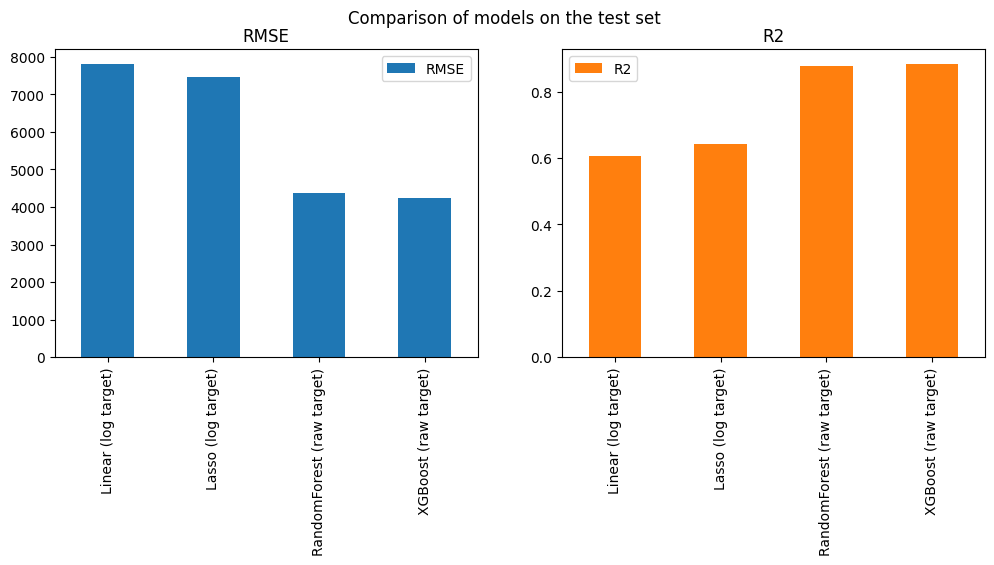

In [69]:
final_df[["RMSE", "R2"]].plot(
    kind="bar", subplots=True, layout=(1, 2), figsize=(12, 4), legend=True
)
plt.suptitle("Comparison of models on the test set")
plt.show()

Conclusions:

**Best model: XGBoost** (slightly better than RandomForest in terms of RMSE and R²).

**RandomForest** and **XGBoost** perform well on a raw target – this shows that nonlinear models handle outliers and nonlinear dependencies in the data well.

**Linear Regression** and **Lasso** trained on log(target) perform better than training on raw data, but still fall short of decision trees.

**Lasso vs. Linear:** Lasso slightly better – regularization reduces overfitting, but the effect is small on this dataset.